In [1]:
from test.helpers import path_l2_dist, SDE, simple_batch_sde_solve, simple_sde_order

import jax
import jax.numpy as jnp
import jax.random as jr
from diffrax import (
    AbstractBrownianPath,
    diffeqsolve,
    Euler,  # noqa: F401
    HalfSolver,
    Heun,
    MultiTerm,
    ODETerm,
    PIDController,
    SABRController,
    SaveAt,
    SpaceTimeLevyArea,
    SPaRK,
    WeaklyDiagonalControlTerm,
)
from drawing_and_evaluating import (
    constant_step_strong_order,  # noqa: F401
    draw_order_multiple_dict,
    load_order_results,  # noqa: F401
    plot_sol_general,
    save_order_results,  # noqa: F401
)


jax.config.update("jax_enable_x64", True)


# Define the SABR model
def drift(t, y, args):
    return jnp.array([0.0, -0.5], dtype=y.dtype)


def diffusion(t, y, args):
    v = y[1]
    sigma = jnp.exp(v)
    return jnp.array([sigma, 1.0], dtype=y.dtype)


def get_terms(bm: AbstractBrownianPath):
    return MultiTerm(ODETerm(drift), WeaklyDiagonalControlTerm(diffusion, bm))


y0 = jnp.array([0.0, 0.0], dtype=jnp.float64)
t0, t1 = 0.0, 10.0
sabr_sde = SDE(get_terms, None, y0, t0, t1, (2,))

half_spark_solver = HalfSolver(SPaRK())
half_heun_solver = HalfSolver(Heun())
num_samples = 10000
key = jr.key(6)
keys = jr.split(key, num_samples)

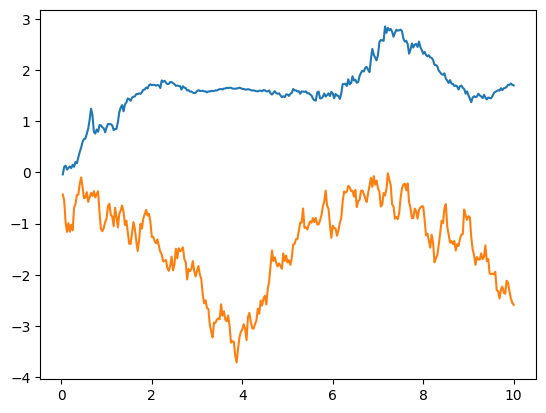

In [10]:
bm_key = jr.key(8)
terms_sabr = get_terms(sabr_sde.get_bm(bm_key, SpaceTimeLevyArea, 2**-6))
sol = diffeqsolve(terms_sabr, SPaRK(), t0, t1, 2**-5, y0, saveat=SaveAt(steps=True))
plot_sol_general(sol)

In [2]:
# spark_const = constant_step_strong_order(keys, sabr_sde, SPaRK(), (4, 10))
# save_order_results(spark_const, "spark_const")
spark_const = load_order_results("spark_const")

# heun_const = constant_step_strong_order(keys, sabr_sde, Heun(), (6, 11))
# save_order_results(heun_const, "heun_const")
heun_const = load_order_results("heun_const")

# euler_const = constant_step_strong_order(keys, sabr_sde, Euler(), (6, 11))
# save_order_results(euler_const, "euler_const")
euler_const = load_order_results("euler_const")

Loaded order_results_spark_const.npy
Loaded order_results_heun_const.npy
Loaded order_results_euler_const.npy


In [3]:
def sabr_strong_order(keys, sde, solver, levels, previsible=False):
    save_ts = jnp.linspace(sde.t0, sde.t1, 65, endpoint=True)
    _saveat = SaveAt(ts=save_ts)
    bm_tol = 2**-10

    def get_sabr_controller(level: int):
        return None, SABRController(
            ctol=2**-level,
            dtmin=2**-9,
            dtmax=1.0,
            step_ts=save_ts,
            previsible=previsible,
        )

    return simple_sde_order(
        keys, sde, solver, solver, levels, get_sabr_controller, _saveat, bm_tol
    )


# spark_sabr = sabr_strong_order(keys, sabr_sde, SPaRK(), (-4, 3))
# save_order_results(spark_sabr, "spark_sabr")
spark_sabr = load_order_results("spark_sabr")

# half_spark_sabr = sabr_strong_order(keys, sabr_sde, half_spark_solver, (-4, 3))
# save_order_results(half_spark_sabr, "half_spark_sabr")
half_spark_sabr = load_order_results("half_spark_sabr")

# heun_sabr = sabr_strong_order(keys, sabr_sde, Heun(), (-4, 3))
# save_order_results(heun_sabr, "heun_sabr")
heun_sabr = load_order_results("heun_sabr")

# half_heun_sabr = sabr_strong_order(keys, sabr_sde, half_heun_solver, (-4, 3))
# save_order_results(half_heun_sabr, "half_heun_sabr")
half_heun_sabr = load_order_results("half_heun_sabr")

spark_previs = sabr_strong_order(keys, sabr_sde, SPaRK(), (-4, 4), previsible=True)
save_order_results(spark_previs, "spark_previs")
# spark_previs = load_order_results("spark_previs")

heun_previs = sabr_strong_order(keys, sabr_sde, Heun(), (-3, 6), previsible=True)
save_order_results(heun_previs, "heun_previs")
# heun_previs = load_order_results("heun_previs")

# euler_previs = sabr_strong_order(keys, sabr_sde, Euler(), (-3, 6), previsible=True)
# save_order_results(euler_previs, "euler_previs")
euler_previs = load_order_results("euler_previs")

Loaded order_results_spark_sabr.npy
Loaded order_results_half_spark_sabr.npy
Loaded order_results_heun_sabr.npy
Loaded order_results_half_heun_sabr.npy
Saved order_results_spark_previs.npy
Saved order_results_heun_previs.npy
Loaded order_results_euler_previs.npy


In [4]:
def pid_strong_order(keys, sde, solver, levels, bm_tol=2**-14):
    save_ts_pid = jnp.linspace(sde.t0, sde.t1, 65, endpoint=True)

    def get_pid(level):
        return None, PIDController(
            pcoeff=0.1,
            icoeff=0.3,
            rtol=0,
            atol=2**-level,
            step_ts=save_ts_pid,
            dtmin=2**-14,
        )

    saveat_pid = SaveAt(ts=save_ts_pid)
    return simple_sde_order(
        keys, sde, solver, solver, levels, get_pid, saveat_pid, bm_tol
    )


spark_pid = pid_strong_order(keys, sabr_sde, SPaRK(), (1, 7))
save_order_results(spark_pid, "spark_pid")
# spark_pid = load_order_results("spark_pid")

# half_spark_pid = pid_strong_order(keys, sabr_sde, half_spark_solver, (0,6))
# save_order_results(half_spark_pid, "half_spark_pid")
half_spark_pid = load_order_results("half_spark_pid")

heun_pid = pid_strong_order(keys, sabr_sde, Heun(), (3, 9))
save_order_results(heun_pid, "heun_pid")
# heun_pid = load_order_results("heun_pid")

# half_heun_pid = pid_strong_order(keys, sabr_sde, half_heun_solver, (1,7))
# save_order_results(half_heun_pid, "half_heun_pid")
half_heun_pid = load_order_results("half_heun_pid")

Saved order_results_spark_pid.npy
Loaded order_results_half_spark_pid.npy
Saved order_results_heun_pid.npy
Loaded order_results_half_heun_pid.npy


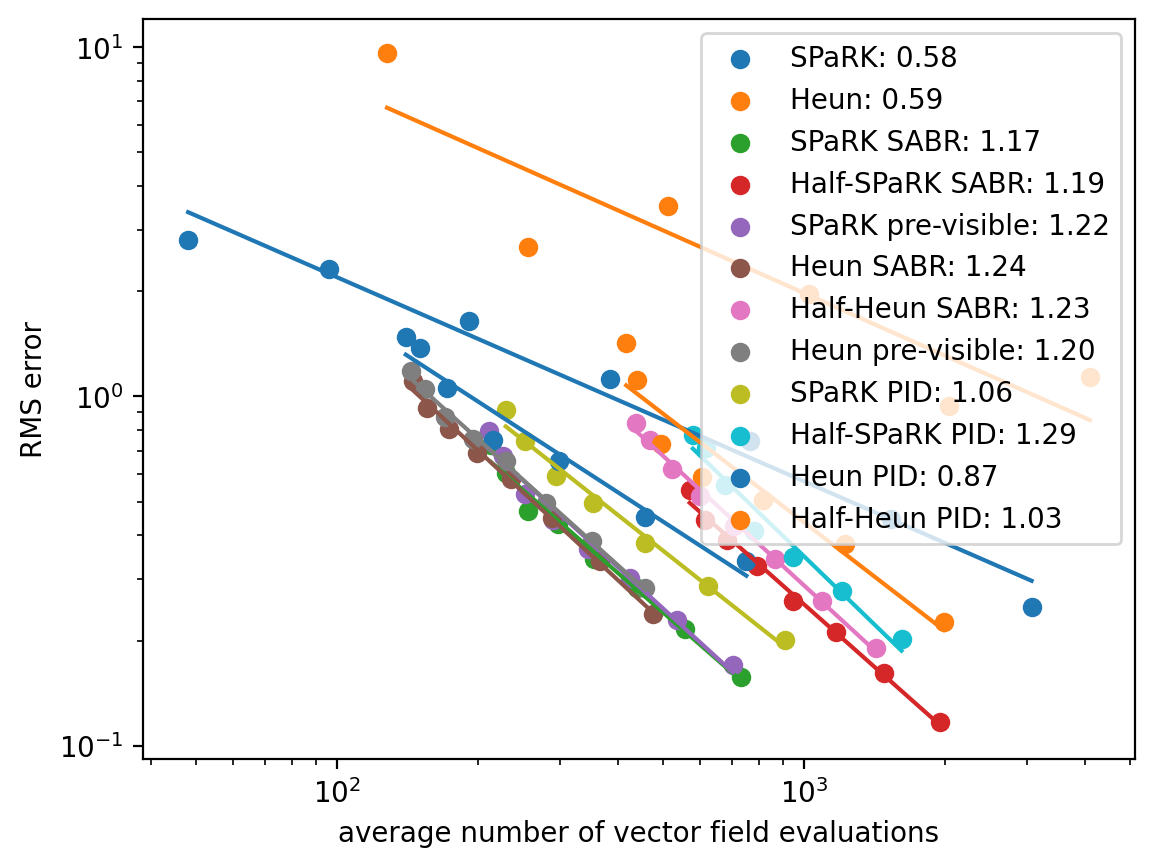

In [9]:
results = {
    "SPaRK": spark_const,
    "Heun": heun_const,
    "SPaRK SABR": spark_sabr,
    "Half-SPaRK SABR": half_spark_sabr,
    "SPaRK pre-visible": spark_previs,
    "Heun SABR": heun_sabr,
    "Half-Heun SABR": half_heun_sabr,
    "Heun pre-visible": heun_previs,
    "SPaRK PID": spark_pid,
    "Half-SPaRK PID": half_spark_pid,
    "Heun PID": heun_pid,
    "Half-Heun PID": half_heun_pid,
}

draw_order_multiple_dict(results)

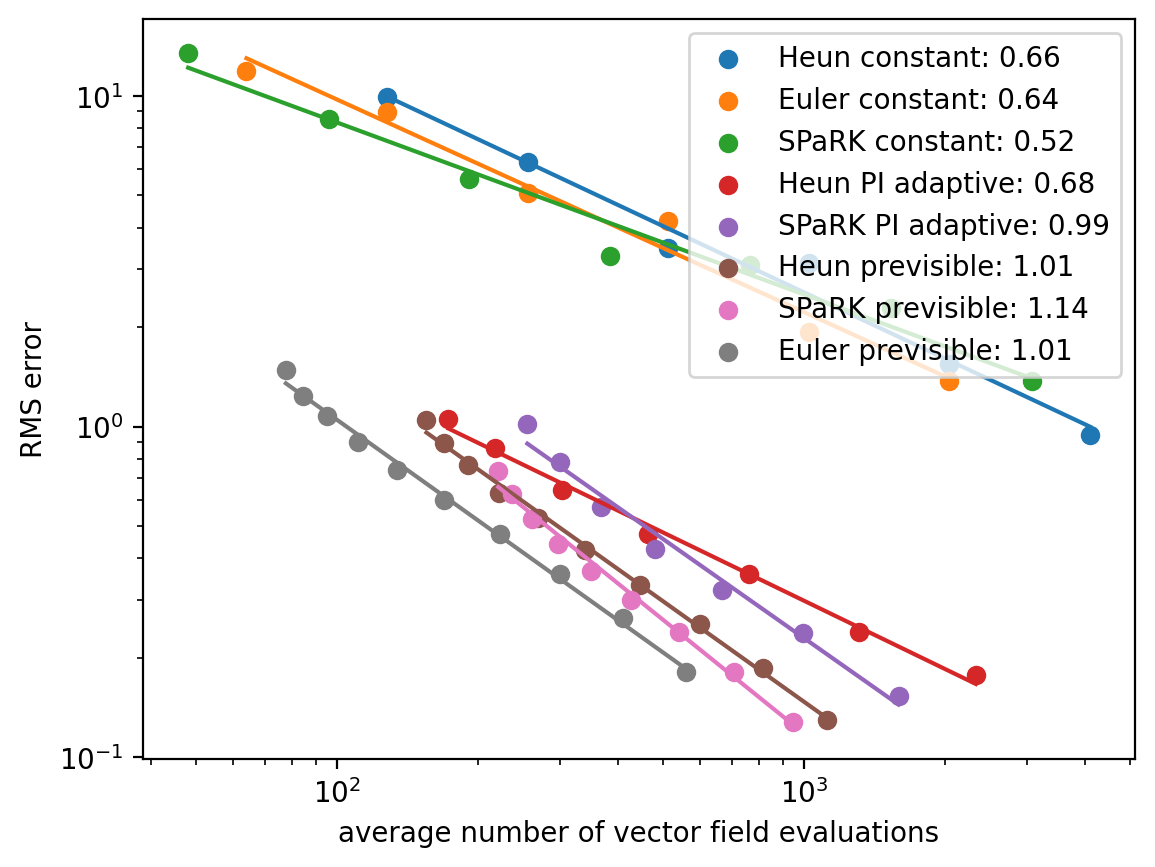

In [5]:
results2 = {
    "Heun constant": heun_const,
    "Euler constant": euler_const,
    "SPaRK constant": spark_const,
    "Heun PI adaptive": heun_pid,
    "SPaRK PI adaptive": spark_pid,
    "Heun previsible": heun_previs,
    "SPaRK previsible": spark_previs,
    "Euler previsible": euler_previs,
}

draw_order_multiple_dict(results2)

In [3]:
# Find good PID parameters
step_ts = jnp.linspace(sabr_sde.t0, sabr_sde.t1, 65, endpoint=True)
ref_controller = PIDController(
    pcoeff=0.1,
    icoeff=0.3,
    rtol=0,
    atol=2**-8,
    step_ts=step_ts,
    dtmin=2**-12,
)
saveat_pid = SaveAt(ts=step_ts)
correct_sols, _ = simple_batch_sde_solve(
    keys, sabr_sde, SPaRK(), SpaceTimeLevyArea, None, ref_controller, 2**-12, saveat_pid
)


def compute_score(icoeff, pcoeff, rtol=0.0):
    controller = PIDController(
        pcoeff=pcoeff,
        icoeff=icoeff,
        rtol=rtol,
        atol=2**-4,
        step_ts=step_ts,
        dtmin=2**-10,
    )
    sols, steps = simple_batch_sde_solve(
        keys, sabr_sde, SPaRK(), SpaceTimeLevyArea, None, controller, 2**-12, saveat_pid
    )
    error = path_l2_dist(sols, correct_sols)
    avg_steps = jnp.mean(steps)
    return error * avg_steps  # We want to minimize this


# Now do a grid search
icoeffs = jnp.linspace(0.1, 1.0, 10, endpoint=True)
pcoeffs = jnp.linspace(0.0, 0.6, 7, endpoint=True)
# rtols = jnp.array([2**-2, 2**-4, 0.0])
import numpy as np


scores = np.zeros((len(icoeffs), len(pcoeffs)))
for i in range(len(icoeffs)):
    for j in range(len(pcoeffs)):
        scores[i, j] = compute_score(icoeffs[i], pcoeffs[j])
        print(
            f"icoeff: {icoeffs[i]:.2}, pcoeff: {pcoeffs[j]:.2},"
            f" score: {scores[i, j]:.5}"
        )

with open("pid_scores.npy", "wb") as f:
    np.save(f, scores)

icoeff: 0.1, pcoeff: 0.0, score: 108.31
icoeff: 0.1, pcoeff: 0.1, score: 115.32
icoeff: 0.1, pcoeff: 0.2, score: 112.74
icoeff: 0.1, pcoeff: 0.3, score: 85.486
icoeff: 0.1, pcoeff: 0.4, score: 84.363
icoeff: 0.1, pcoeff: 0.5, score: 73.054
icoeff: 0.1, pcoeff: 0.6, score: 67.739
icoeff: 0.2, pcoeff: 0.0, score: 72.922
icoeff: 0.2, pcoeff: 0.1, score: 73.413
icoeff: 0.2, pcoeff: 0.2, score: 64.973
icoeff: 0.2, pcoeff: 0.3, score: 62.818
icoeff: 0.2, pcoeff: 0.4, score: 58.036
icoeff: 0.2, pcoeff: 0.5, score: 54.825
icoeff: 0.2, pcoeff: 0.6, score: 56.092
icoeff: 0.3, pcoeff: 0.0, score: 52.488
icoeff: 0.3, pcoeff: 0.1, score: 51.784
icoeff: 0.3, pcoeff: 0.2, score: 55.967
icoeff: 0.3, pcoeff: 0.3, score: 54.168
icoeff: 0.3, pcoeff: 0.4, score: 52.022
icoeff: 0.3, pcoeff: 0.5, score: 52.403
icoeff: 0.3, pcoeff: 0.6, score: 51.689
icoeff: 0.4, pcoeff: 0.0, score: 49.851
icoeff: 0.4, pcoeff: 0.1, score: 50.724
icoeff: 0.4, pcoeff: 0.2, score: 50.287
icoeff: 0.4, pcoeff: 0.3, score: 46.361


In [4]:
# Find the 10 lowest scores
scores = np.load("pid_scores.npy")
best_indices = np.unravel_index(np.argsort(scores, axis=None), scores.shape)
best_indices = (best_indices[0][:10], best_indices[1][:10])
best_scores = scores[best_indices]
best_icoeffs = icoeffs[best_indices[0]]
best_pcoeffs = pcoeffs[best_indices[1]]
print("Best scores:")
for i in range(10):
    print(
        f"icoeff: {best_icoeffs[i]:.2}, pcoeff: {best_pcoeffs[i]:.2},"
        f" score: {best_scores[i]:.5}"
    )

Best scores:
icoeff: 0.6, pcoeff: 0.5, score: 45.244
icoeff: 0.6, pcoeff: 0.0, score: 45.612
icoeff: 0.5, pcoeff: 0.1, score: 45.613
icoeff: 0.4, pcoeff: 0.3, score: 46.361
icoeff: 0.8, pcoeff: 0.5, score: 46.898
icoeff: 0.9, pcoeff: 0.1, score: 46.967
icoeff: 0.7, pcoeff: 0.5, score: 47.061
icoeff: 0.8, pcoeff: 0.1, score: 47.213
icoeff: 1.0, pcoeff: 0.0, score: 47.593
icoeff: 0.6, pcoeff: 0.6, score: 47.811
